# Train transformer model on transformed experimental time series data

Using the preprocessed time series data from the `transformed_exp_time_series_data/` folder:
- 19316_2020_10_26_steadystate_glucose_144m_2w2_00 (label: 0)
- 20213_2021_09_07_steady_0p01glc_1344_1346_1347_00 (label: 1)

Each file contains individual cell time series data ready for classification.

In [7]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Load time series data from transformed_exp_time_series_data folder
data_path = "../transformed_exp_time_series_data/"
csv_files = glob.glob(data_path + "*.csv")

print(f"Found {len(csv_files)} CSV files")

# Load and combine all time series data
all_sequences = []
all_labels = []

for file in csv_files:
    df = pd.read_csv(file)
    
    # Extract experiment type from filename for labeling
    if "19316_2020_10_26" in file:
        label = 0  # glucose condition
    elif "20213_2021_09_07" in file:
        label = 1  # low glucose condition
    else:
        continue  # skip other experiments for now
    
    # Convert to numpy array (excluding any non-numeric columns if present)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    sequence = df[numeric_cols].values
    
    all_sequences.append(sequence)
    all_labels.append(label)

X = np.array(all_sequences, dtype=object)
y = np.array(all_labels)

print(f"Number of sequences: {len(X)}")
print(f"Labels distribution: {np.bincount(y)}")
print(f"Sample sequence shape: {X[0].shape}")
print(f"Number of features per timepoint: {X[0].shape[1]}")

Found 34 CSV files
Number of sequences: 6
Labels distribution: [3 3]
Sample sequence shape: (241, 147)
Number of features per timepoint: 147


In [8]:
# Prepare time series sequences for transformer training
from sklearn.model_selection import train_test_split

# Use the data as-is since it's already properly formatted
sequence_lengths = [seq.shape[0] for seq in X]
print(f"Sequence lengths - Min: {min(sequence_lengths)}, Max: {max(sequence_lengths)}, Mean: {np.mean(sequence_lengths):.2f}")

Sequence lengths - Min: 71, Max: 275, Mean: 163.33


In [9]:
# Prepare fixed-length sequences for transformer
def pad_or_truncate_sequences(sequences, target_length=450, target_features=None):
    # Make both sequence length and feature count consistent across all samples.
    if target_features is None:
        target_features = min(seq.shape[1] for seq in sequences)

    padded_sequences = []
    for seq in sequences:
        seq = np.asarray(seq, dtype=float)

        # Align feature dimension first
        if seq.shape[1] > target_features:
            seq = seq[:, :target_features]
        elif seq.shape[1] < target_features:
            feature_padding = np.zeros((seq.shape[0], target_features - seq.shape[1]), dtype=float)
            seq = np.hstack([seq, feature_padding])

        # Then align sequence length
        if len(seq) > target_length:
            padded_seq = seq[:target_length]
        else:
            padding = np.zeros((target_length - len(seq), target_features), dtype=float)
            padded_seq = np.vstack([seq, padding])

        padded_sequences.append(padded_seq)

    return np.stack(padded_sequences, axis=0)

target_length = 450
X_padded = pad_or_truncate_sequences(X, target_length)
print(f"Using shape: {X_padded.shape} (samples, seq_len, features)")

# Split the data robustly for very small datasets
class_counts = np.bincount(y)
can_do_two_stage_stratified = len(y) >= 10 and np.min(class_counts) >= 3

if can_do_two_stage_stratified:
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_padded, y, test_size=0.4, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )
else:
    # Fallback for tiny datasets: stratified train/test, reuse test as validation
    X_train, X_test, y_train, y_test = train_test_split(
        X_padded, y, test_size=0.33, random_state=42, stratify=y
    )
    X_val, y_val = X_test.copy(), y_test.copy()
    print("Dataset too small for stable train/val/test stratification; using test set as validation set.")

print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
print(f"Class counts - train: {np.bincount(y_train)}, val: {np.bincount(y_val)}, test: {np.bincount(y_test)}")

Using shape: (6, 450, 90) (samples, seq_len, features)
Dataset too small for stable train/val/test stratification; using test set as validation set.
Training: (4, 450, 90), Validation: (2, 450, 90), Test: (2, 450, 90)
Class counts - train: [2 2], val: [1 1], test: [1 1]


In [10]:
# Train transformer classifier
from classifiers.transformer_classifier import transformer_classifier

hyperparams = {
    'input_size': X_train.shape[2],
    'd_model': 128,
    'nhead': 4,
    'num_layers': 2,
    'num_classes': 2,
    'dropout': 0.1,
    'learning_rate': 0.01,
    'batch_size': 64,
    'epochs': 50,
    'patience': 5,
    'optimizer': 'Adam',
    'use_conv1d': False,
    'use_auxiliary': False,
    'pooling_strategy': 'last',
    'use_mask': False,
    'gradient_clip': 1.0
}

test_accuracy = transformer_classifier(X_train, X_val, X_test, y_train, y_val, y_test, **hyperparams)
print(f"Transformer Test Accuracy: {test_accuracy:.4f}")

Starting training...


Epoch [1/50] | train_loss 0.7442 | train_acc 0.5000 | val_loss 0.2494 | val_acc 1.0000
No improvement (1/5).
Epoch [2/50] | train_loss 0.2363 | train_acc 1.0000 | val_loss 0.0598 | val_acc 1.0000
No improvement (2/5).
Epoch [3/50] | train_loss 0.0542 | train_acc 1.0000 | val_loss 0.0129 | val_acc 1.0000
No improvement (3/5).
Epoch [4/50] | train_loss 0.0126 | train_acc 1.0000 | val_loss 0.0021 | val_acc 1.0000
No improvement (4/5).
Epoch [5/50] | train_loss 0.0023 | train_acc 1.0000 | val_loss 0.0004 | val_acc 1.0000
No improvement (5/5).
🛑 Early stopping.
Training complete.
Test — loss: N/A | acc: 1.00
=== Vanilla Transformer Accuracy: 1.00 ===
Transformer Test Accuracy: 1.0000


=== SVM (RBF Kernel) Classification Accuracy: 0.50 ===
=== SVM (Linear Kernel) Classification Accuracy: 0.50 ===
=== Random Forest Accuracy: 1.00 ===
=== Logistic Regression Accuracy: 0.50 ===
🔄 Using device: cuda (1 GPUs available)
DEBUG: Optimizer initialized? True
✅ Running on CUDA!
Epoch [1/10], Loss: 1.4974, Train Acc: 0.2500
Validation Acc: 1.0000
Epoch [2/10], Loss: 0.0001, Train Acc: 1.0000
Validation Acc: 1.0000
No improvement (1/10).
Epoch [3/10], Loss: 0.0000, Train Acc: 1.0000
Validation Acc: 1.0000
No improvement (2/10).
Epoch [4/10], Loss: 0.0000, Train Acc: 1.0000
Validation Acc: 1.0000
No improvement (3/10).
Epoch [5/10], Loss: 0.0000, Train Acc: 1.0000
Validation Acc: 1.0000
No improvement (4/10).
Epoch [6/10], Loss: 0.0000, Train Acc: 1.0000
Validation Acc: 1.0000
No improvement (5/10).
Epoch [7/10], Loss: 0.0000, Train Acc: 1.0000
Validation Acc: 1.0000
No improvement (6/10).
Epoch [8/10], Loss: 0.0000, Train Acc: 1.0000
Validation Acc: 1.0000
No improvement (7/10).


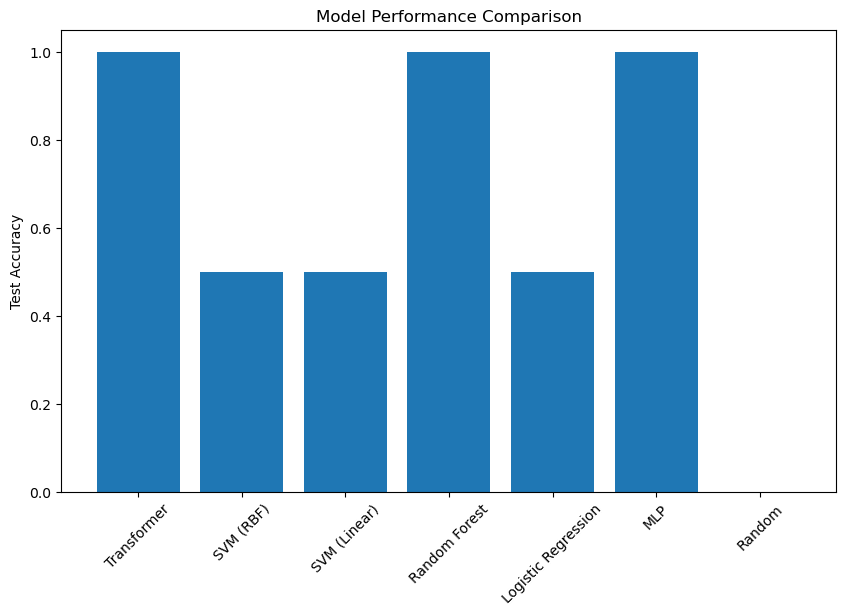

In [11]:
# Benchmark all classifiers
from classifiers.svm_classifier import svm_classifier
from classifiers.random_forest_classifier import random_forest_classifier  
from classifiers.logistic_regression_classifier import logistic_regression_classifier
from classifiers.mlp_classifier import mlp_classifier
from classifiers.random_classifier import random_classifier

# Extract statistical features for traditional ML models
def extract_statistical_features(X):
    features = []
    for seq in X:
        seq_features = []
        for feature_idx in range(seq.shape[1]):
            feature_series = seq[:, feature_idx]
            non_zero_mask = feature_series != 0
            if np.any(non_zero_mask):
                clean_series = feature_series[non_zero_mask]
                seq_features.extend([np.mean(clean_series), np.std(clean_series), 
                                   np.min(clean_series), np.max(clean_series), np.median(clean_series)])
            else:
                seq_features.extend([0, 0, 0, 0, 0])
        features.append(seq_features)
    return np.array(features)

X_train_features = extract_statistical_features(X_train)
X_test_features = extract_statistical_features(X_test)
X_val_features = extract_statistical_features(X_val)

# Train and evaluate all models
results = {'Transformer': test_accuracy}
results['SVM (RBF)'] = svm_classifier(X_train_features, X_test_features, y_train, y_test, svm_kernel='rbf')
results['SVM (Linear)'] = svm_classifier(X_train_features, X_test_features, y_train, y_test, svm_kernel='linear')
results['Random Forest'] = random_forest_classifier(X_train_features, X_test_features, y_train, y_test)
results['Logistic Regression'] = logistic_regression_classifier(X_train_features, X_test_features, y_train, y_test)
results['MLP'] = mlp_classifier(X_train_features, X_val_features, X_test_features, y_train, y_val, y_test)
results['Random'] = random_classifier(y_test)

# Display results
for model, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model}: {acc:.4f}")

# Simple visualization
plt.figure(figsize=(10, 6))
models = list(results.keys())
accuracies = list(results.values())
plt.bar(models, accuracies)
plt.title('Model Performance Comparison')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=45)
plt.show()